# Advanced-2. From Custom Targets to Noisy Simulation with Mirrored Circuits

In this chapter, we define and simulate on a noisy virtual environment:

1. define a custom backend-like `Target`,  
2. build a random native-gate circuit block $U$,  
3. mirror it into
   $$
   U\;\texttt{barrier}\;U^\dagger,
   $$
4. transpile it against the custom target, and  
5. simulate the compiled circuit both **ideally** and **with noise**.

A mirrored circuit is useful because, in the absence of noise, it should return to the input basis state.
If we start from $\lvert 0000\rangle$, then the ideal output should be concentrated on `0000`.
This makes noise effects easy to see directly in the measurement results.

The main lesson is:

- the `Target` defines the **instruction set and hardware-like metadata** used for transpilation,
- the **noise model** defines the stochastic errors used during simulation,
- and the noisy simulation results show how these two pieces interact in practice.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit.library import RZGate, SXGate, XGate, Measure, ECRGate

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error


## A2-1. Define a Custom Target

We first define a small 4-qubit custom target with a **linear nearest-neighbor** topology.
The native instruction set will be:

- single-qubit `rz`, `sx`, `x`,
- two-qubit `ecr`,
- and terminal measurement.

The `Target` stores both **which operations are allowed** and optional metadata such as
durations and nominal error rates. These error rates do not automatically inject noise by themselves,
but they are useful for two purposes:

1. they document the intended hardware conditions, and  
2. we can later convert them into an Aer `NoiseModel` for simulation.


In [18]:
def make_custom_target(
    n_qubits=4,
    ecr_error=0.02,
    sx_error=3e-4,
    x_error=3e-4,
    meas_error=0.03,
    ecr_duration=5.0e-7,
    sx_duration=3.5e-8,
    x_duration=3.5e-8,
    meas_duration=1.2e-6,
):
    target = Target(num_qubits=n_qubits)

    rz_props = {(q,): InstructionProperties(duration=0.0, error=0.0) for q in range(n_qubits)}
    sx_props = {(q,): InstructionProperties(duration=sx_duration, error=sx_error) for q in range(n_qubits)}
    x_props = {(q,): InstructionProperties(duration=x_duration, error=x_error) for q in range(n_qubits)}
    meas_props = {(q,): InstructionProperties(duration=meas_duration, error=meas_error) for q in range(n_qubits)}

    ecr_props = {}
    for q in range(n_qubits - 1):
        ecr_props[(q, q + 1)] = InstructionProperties(duration=ecr_duration, error=ecr_error)
        ecr_props[(q + 1, q)] = InstructionProperties(duration=ecr_duration, error=ecr_error)

    target.add_instruction(RZGate(0.0), rz_props, name="rz")
    target.add_instruction(SXGate(), sx_props, name="sx")
    target.add_instruction(XGate(), x_props, name="x")
    target.add_instruction(ECRGate(), ecr_props, name="ecr")
    target.add_instruction(Measure(), meas_props, name="measure")
    return target


target = make_custom_target()

## A2-2. Build a Random Mirrored Circuit

Next we generate a random native-gate block $U$ using only operations supported by the target.
Then we mirror it into
$$
U\;\texttt{barrier}\;U^\dagger.
$$

This structure is intentionally simple to interpret:

- ideally, $U^\dagger$ should exactly undo $U$,
- so the final state should return to $\lvert 0000\rangle$,
- and any spread in the measured output distribution can then be attributed to noise and sampling.

Because the block is already native, the transpiler mainly has to respect the target structure
rather than synthesize an entirely different gate set.


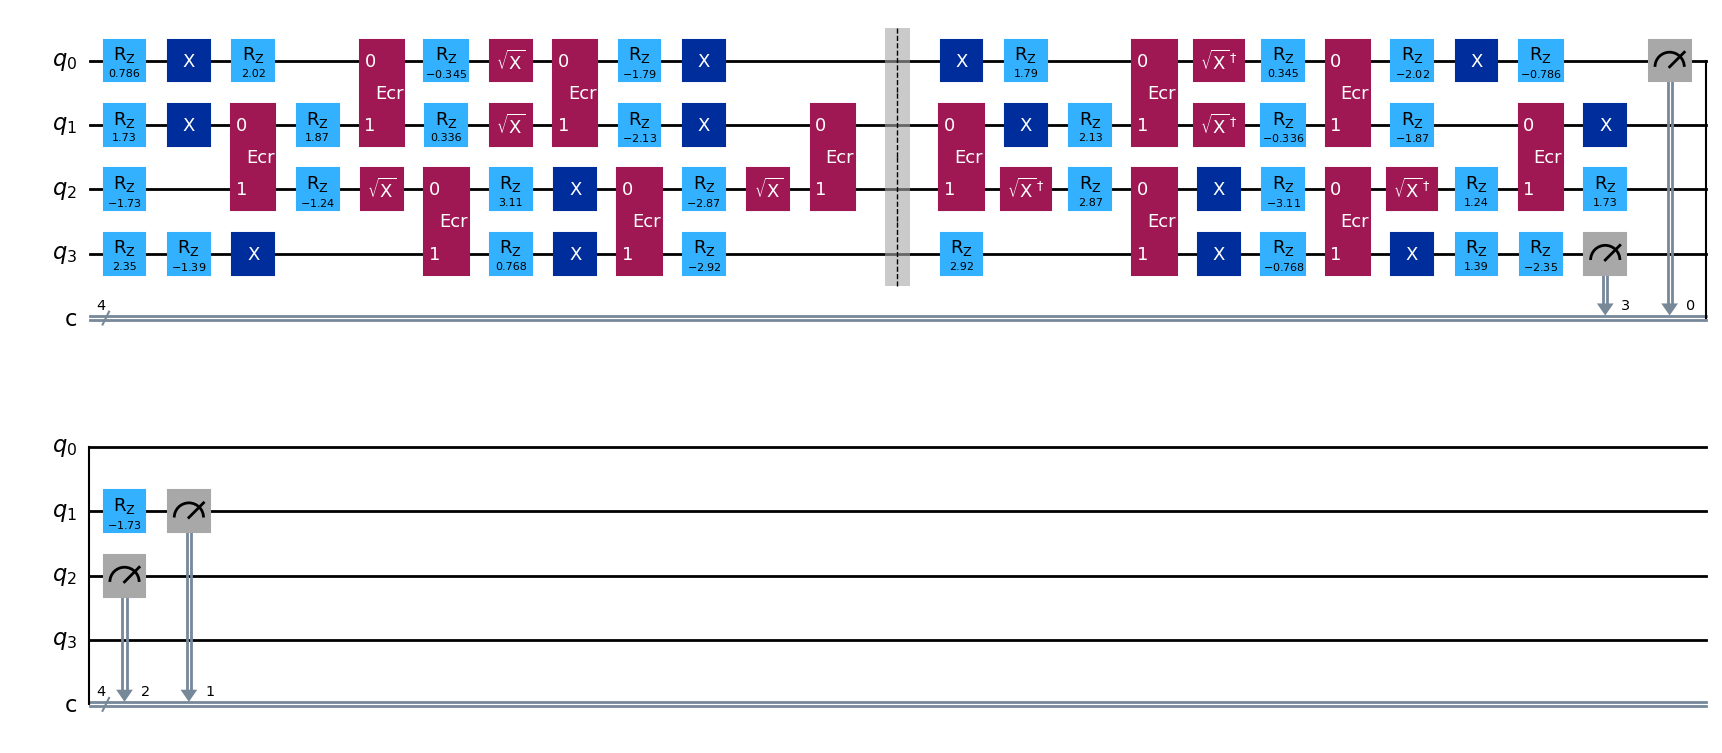

In [19]:
def make_random_native_block(n_qubits=4, depth=4, seed=1234):
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(n_qubits)

    for _ in range(depth):
        for q in range(n_qubits):
            qc.rz(float(rng.uniform(-np.pi, np.pi)), q)
            choice = int(rng.integers(3))
            if choice == 1:
                qc.sx(q)
            elif choice == 2:
                qc.x(q)

        offset = int(rng.integers(2))
        for q in range(offset, n_qubits - 1, 2):
            qc.ecr(q, q + 1)

    return qc


def make_mirrored_circuit(n_qubits=4, depth=4, seed=1234):
    U = make_random_native_block(n_qubits=n_qubits, depth=depth, seed=seed)
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.compose(U, inplace=True)
    qc.barrier()
    qc.compose(U.inverse(), inplace=True)
    qc.measure(range(n_qubits), range(n_qubits))
    return qc, U


mirror_circuit, U_block = make_mirrored_circuit(depth=4, seed=7)
mirror_circuit.draw("mpl")


## A2-3. Transpile the Mirrored Circuit onto the Custom Target

Now we compile the mirrored circuit against the custom target.
This step answers the compilation question:

> how is the abstract circuit rewritten into the ISA supported by this target?

Since the random block already uses native instructions, the transpiled circuit should remain close
to the original structure. Still, it is useful to inspect the compiled circuit and the stored
instruction metadata before moving on to simulation.


In [20]:
isa_circuit = transpile(
    mirror_circuit,
    target=target,
    optimization_level=3,
    seed_transpiler=1234,
)

summary = {
    "original_depth": mirror_circuit.depth(),
    "isa_depth": isa_circuit.depth(),
    "original_size": mirror_circuit.size(),
    "isa_size": isa_circuit.size(),
    "isa_ops": dict(isa_circuit.count_ops()),
}
summary


{'original_depth': 25,
 'isa_depth': 26,
 'original_size': 70,
 'isa_size': 69,
 'isa_ops': {'rz': 31,
  'x': 14,
  'ecr': 12,
  'sx': 8,
  'measure': 4,
  'barrier': 1}}

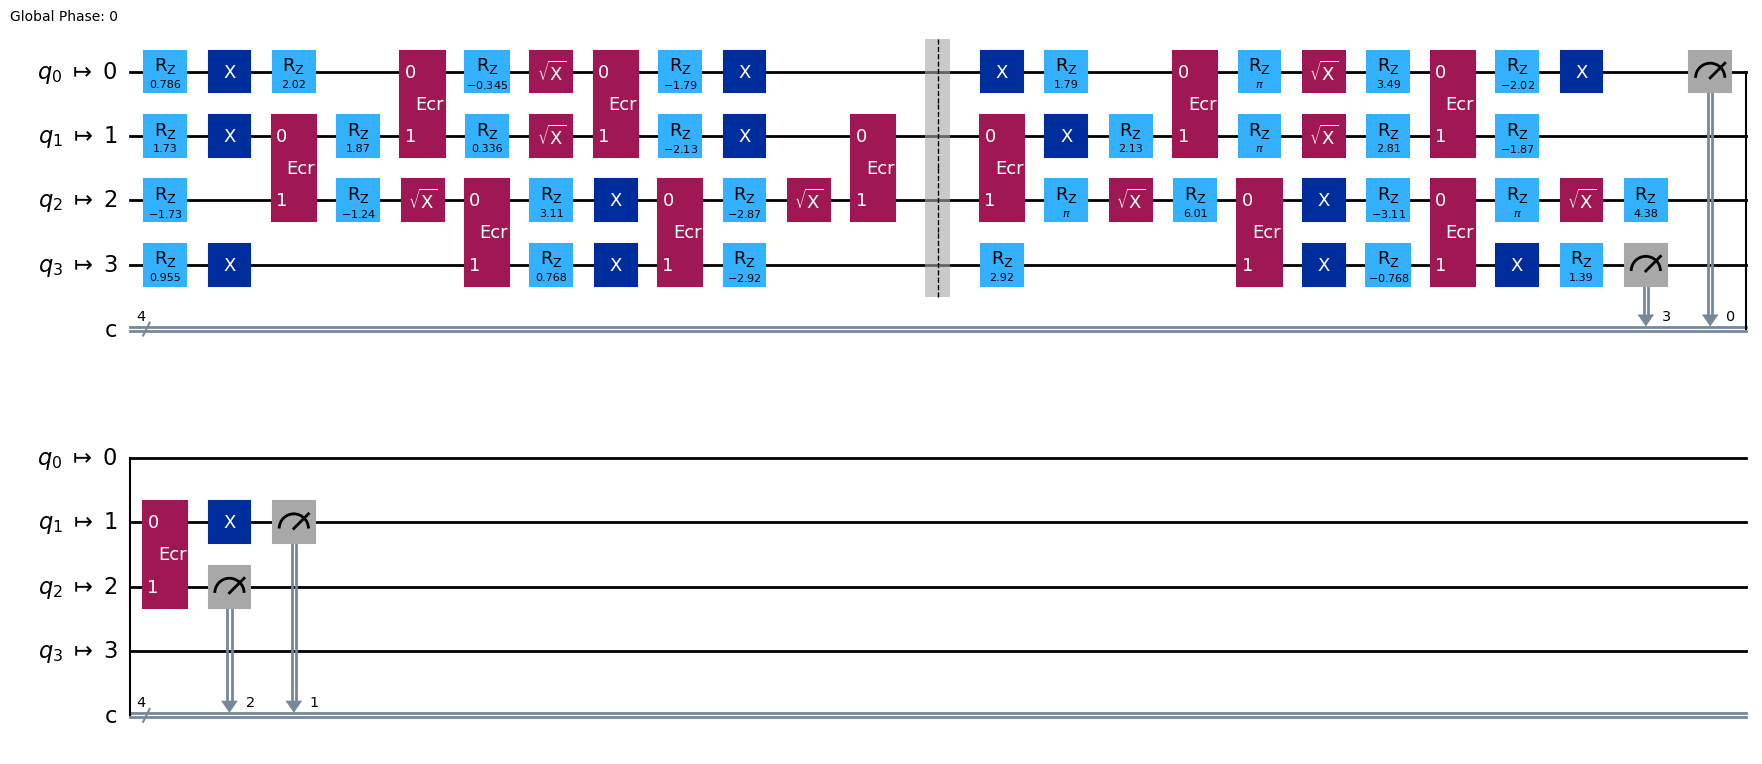

In [21]:
isa_circuit.draw("mpl", idle_wires=False)


In [22]:
print("Custom target properties:")
for inst, qargs in target.instructions:
    props = target[inst.name].get(qargs, None)
    if props is not None and getattr(props, "error", None) is not None:
        print(f"{inst.name:8s} on {qargs}: error={props.error}, duration={props.duration}")


Custom target properties:
rz       on (0,): error=0.0, duration=0.0
rz       on (1,): error=0.0, duration=0.0
rz       on (2,): error=0.0, duration=0.0
rz       on (3,): error=0.0, duration=0.0
sx       on (0,): error=0.0003, duration=3.5e-08
sx       on (1,): error=0.0003, duration=3.5e-08
sx       on (2,): error=0.0003, duration=3.5e-08
sx       on (3,): error=0.0003, duration=3.5e-08
x        on (0,): error=0.0003, duration=3.5e-08
x        on (1,): error=0.0003, duration=3.5e-08
x        on (2,): error=0.0003, duration=3.5e-08
x        on (3,): error=0.0003, duration=3.5e-08
ecr      on (0, 1): error=0.02, duration=5e-07
ecr      on (1, 0): error=0.02, duration=5e-07
ecr      on (1, 2): error=0.02, duration=5e-07
ecr      on (2, 1): error=0.02, duration=5e-07
ecr      on (2, 3): error=0.02, duration=5e-07
ecr      on (3, 2): error=0.02, duration=5e-07
measure  on (0,): error=0.03, duration=1.2e-06
measure  on (1,): error=0.03, duration=1.2e-06
measure  on (2,): error=0.03, duration

## A2-4. Convert the Target Metadata into a Noise Model

The `Target` itself does not simulate noise.
To perform a noisy simulation, we convert the stored error metadata into an **Qiskit-Aer** `NoiseModel`.

This is not a full hardware calibration model, but it is enough to demonstrate the distinction between

- **compilation constraints** from the target, and
- **execution noise** from the simulator.


In [23]:
raise Warning("noise model building is not perfect.")

def make_noise_model_from_target(target):
    noise_model = NoiseModel()

    for gate_name in target.operation_names:
        if gate_name == "measure":
            continue
        for qargs, props in target[gate_name].items():
            n_qubits = len(qargs)
            if props is None or props.error is None or props.error <= 0:
                continue
            noise_model.add_quantum_error(
                depolarizing_error(props.error, n_qubits),
                [gate_name],
                list(qargs),
            )

    if "measure" in target.operation_names:
        for qargs, props in target["measure"].items():
            if props is None or props.error is None or props.error <= 0:
                continue
            p = float(props.error)
            readout = ReadoutError([[1 - p, p], [p, 1 - p]])
            noise_model.add_readout_error(readout, list(qargs))

    return noise_model


noise_model = make_noise_model_from_target(target)
noise_model


<NoiseModel on ['sx', 'measure', 'x', 'ecr']>

## A2-5. Compare Ideal and Noisy Simulation Results

We now compare the **actual measurement results** of the same compiled mirrored circuit under two conditions:

1. **ideal simulation**, and  
2. **noisy simulation** using the noise model built from the target.

We will look at two views:

- the output probability distribution for one representative mirrored circuit, and
- the success probability
  $$
  P(0000)
  $$
  as the mirrored-block depth increases.

The second view is especially useful because a deeper mirrored circuit uses more gates, so it accumulates more noise.
If noise is significant, then the probability of returning to `0000` should decrease as depth grows.


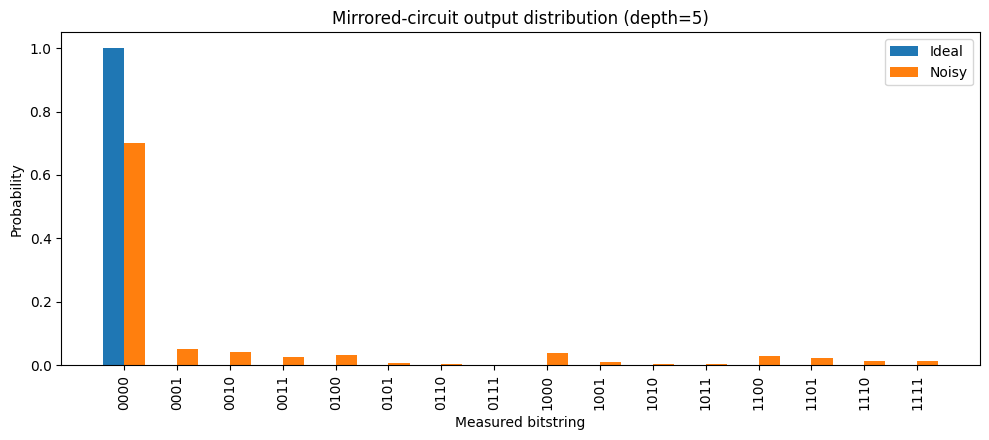

Ideal   P(0000) = 1.0000
Noisy   P(0000) = 0.6997


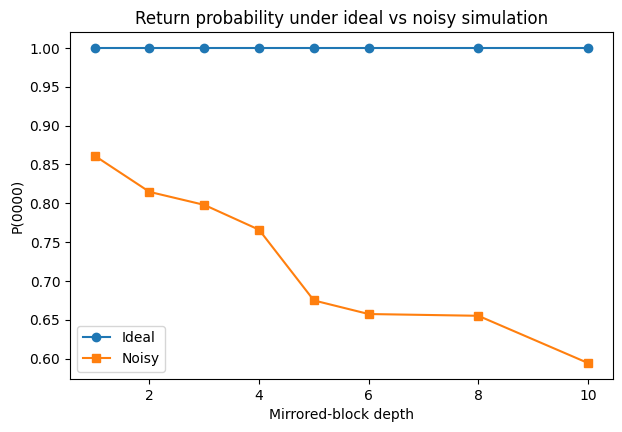

In [24]:
def normalize_counts(counts, n_qubits=4):
    all_states = [format(i, f"0{n_qubits}b") for i in range(2**n_qubits)]
    total = sum(counts.values())
    if total == 0:
        return {state: 0.0 for state in all_states}
    return {state: counts.get(state, 0) / total for state in all_states}


ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise_model)

# One representative circuit
shots = 4000
depth_demo = 5
demo_circuit, _ = make_mirrored_circuit(depth=depth_demo, seed=21)
demo_isa = transpile(demo_circuit, target=target, optimization_level=3, seed_transpiler=1234)

ideal_counts = ideal_sim.run(demo_isa, shots=shots).result().get_counts()
noisy_counts = noisy_sim.run(demo_isa, shots=shots).result().get_counts()

ideal_probs = normalize_counts(ideal_counts, n_qubits=4)
noisy_probs = normalize_counts(noisy_counts, n_qubits=4)

states = list(ideal_probs.keys())
x = np.arange(len(states))
width = 0.4

plt.figure(figsize=(10, 4.5))
plt.bar(x - width / 2, [ideal_probs[s] for s in states], width=width, label="Ideal")
plt.bar(x + width / 2, [noisy_probs[s] for s in states], width=width, label="Noisy")
plt.xticks(x, states, rotation=90)
plt.xlabel("Measured bitstring")
plt.ylabel("Probability")
plt.title(f"Mirrored-circuit output distribution (depth={depth_demo})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Ideal   P(0000) = {ideal_probs['0000']:.4f}")
print(f"Noisy   P(0000) = {noisy_probs['0000']:.4f}")

# Success probability versus mirrored depth
depth_grid = [1, 2, 3, 4, 5, 6, 8, 10]
p0000_ideal = []
p0000_noisy = []

for depth in depth_grid:
    qc, _ = make_mirrored_circuit(depth=depth, seed=100 + depth)
    isa = transpile(qc, target=target, optimization_level=3, seed_transpiler=1234)

    counts_ideal = ideal_sim.run(isa, shots=shots).result().get_counts()
    counts_noisy = noisy_sim.run(isa, shots=shots).result().get_counts()

    probs_ideal = normalize_counts(counts_ideal, n_qubits=4)
    probs_noisy = normalize_counts(counts_noisy, n_qubits=4)

    p0000_ideal.append(probs_ideal["0000"])
    p0000_noisy.append(probs_noisy["0000"])

plt.figure(figsize=(7, 4.5))
plt.plot(depth_grid, p0000_ideal, marker="o", label="Ideal")
plt.plot(depth_grid, p0000_noisy, marker="s", label="Noisy")
plt.xlabel("Mirrored-block depth")
plt.ylabel("P(0000)")
plt.title("Return probability under ideal vs noisy simulation")
plt.legend()
plt.show()


## A2-6. Interpretation

This experiment makes the division of roles precise.

1. The `Target` defines the **hardware abstraction for transpilation**:
   legal operations, qubit connectivity, and metadata such as durations and nominal errors.

2. The Aer `NoiseModel` defines the **stochastic error process during execution**.

3. The mirrored circuit gives a clear success criterion:
   in the ideal case the final state should return to `0000`,
   while in the noisy case the output distribution spreads and the return probability decreases.

So the most meaningful comparison here is not between two ISA circuits that happen to transpile similarly,
but between the **ideal and noisy simulation results** of the same compiled circuit family.
